In [116]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [135]:
# Constantes

G = 6.67430e-11  # m^3 kg^-1 s^-2
r_limits = [1221e3, 3480e3, 6346e3, 6371e3] # Sacados del PREM

def get_phi(vp, vs):
    return vp**2 - (4/3 * vs**2)

# Propiedades por capa: {rho_inicial, phi, gamma}
layers = {
    "inner_core": {"rho": 13088.5, "phi": get_phi(11262.2, 3667.8), "gamma": 1.5}, # Gamma sale de Anderson, O. (1989). Theory of the Earth
    "outer_core": {"rho": 11190.67, "phi": get_phi(11048.7, 0), "gamma": 1.5},
    "mantle": {"rho": 5319.7, "phi": get_phi(15389.1, 6925.4), "gamma": 1.1},
    "crust": {"rho": 2900, "phi": get_phi(6800, 3900), "gamma": 1.0},
}


In [136]:
# Sistema de ecuaciones diferenciales
def derivatives(r, y):
    rho, g, m, P, T = y
    if r < r_limits[0]:  # Inner core
        layer = layers["inner_core"]
    elif r < r_limits[1]:  # Outer core
        layer = layers["outer_core"]
    elif r < r_limits[2]:  # Mantle
        layer = layers["mantle"]
    else:  # Crust
        layer = layers["crust"]
    
    Ks = layer["phi"] * layer["rho"]

    drrho = -rho * g / layer["phi"]
    drg = 4 * np.pi * G * rho - (2 * G * m) / (r**3 + 1e-8)  # Evitar división por cero
    drm = 4 * np.pi * r**2 * rho
    drP = -rho * g
    drT = - ((rho * g * T) / Ks) * layer["gamma"]

    return np.array([drrho, drg, drm, drP, drT])

In [137]:
def solve_planet(rho_c, p_c, t_c):
    r_start = 100.0  # Iniciar cerca de cero para estabilidad
    y_init = [rho_c, 0.0, 0.0, p_c, t_c]
    
    all_r = []
    all_y = []
    
    for i in range(len(r_limits)):
        r_end = r_limits[i]
        
        # solve_ivp con paso adaptativo RK45
        sol = solve_ivp(derivatives, (r_start, r_end), y_init,  method='RK45', t_eval=np.linspace(r_start, r_end, 1000))
        
        all_r.append(sol.t)
        all_y.append(sol.y)
        
        # Actualización para la siguiente capa (Condiciones de continuidad + salto de rho)
        if i < len(r_limits) - 1:
            y_last = sol.y[:, -1]
            next_layer = list(layers.keys())[i+1]
            
            y_init = list(y_last)
            y_init[0] = layers[next_layer]['rho'] # Aplicar discontinuidad de densidad
            r_start = r_end
            
    return np.concatenate(all_r), np.hstack(all_y)

# --- EJECUCIÓN ---
# Valores centrales estimados para la Tierra
r_res, y_res = solve_planet(13050, 3.6e11, 6000)

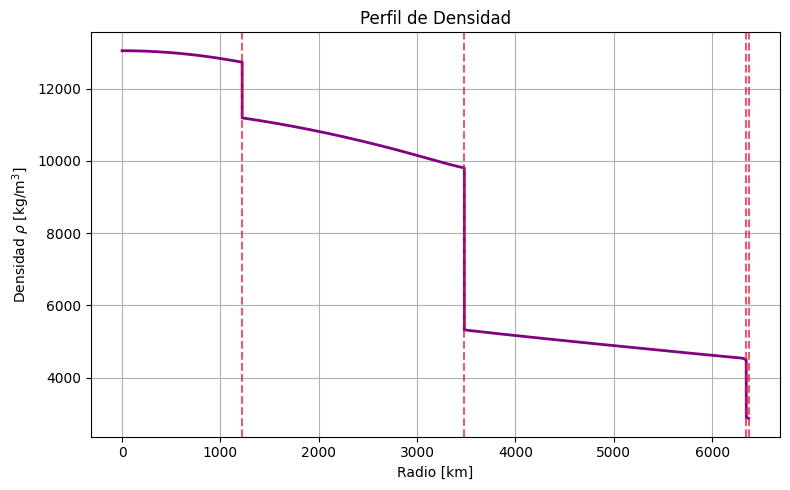

In [138]:
# Graficar cada capa por separado

r_km = r_res / 1e3

# Densidad 

plt.figure(figsize=(8, 5))
plt.plot(r_km, y_res[0], color='purple', lw=2)
plt.xlabel('Radio [km]')
plt.ylabel(r'Densidad $\rho$ [kg/m$^3$]')
plt.grid(True)
for boundary in r_limits[:]:
    plt.axvline(boundary/1e3, color='crimson', linestyle='--', alpha=0.7)
plt.title('Perfil de Densidad')
plt.tight_layout()
plt.show()

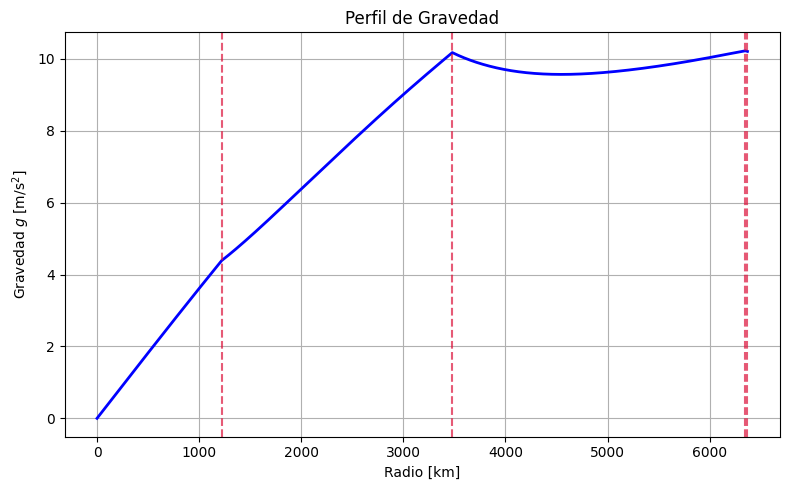

In [139]:
# gravedad

plt.figure(figsize=(8, 5))
plt.plot(r_km, y_res[1], color='blue', lw=2)
plt.xlabel('Radio [km]')
plt.ylabel(r'Gravedad $g$ [m/s$^2$]')
plt.grid(True)
for boundary in r_limits[:]:
    plt.axvline(boundary/1e3, color='crimson', linestyle='--', alpha=0.7)
plt.title('Perfil de Gravedad')
plt.tight_layout()
plt.show()

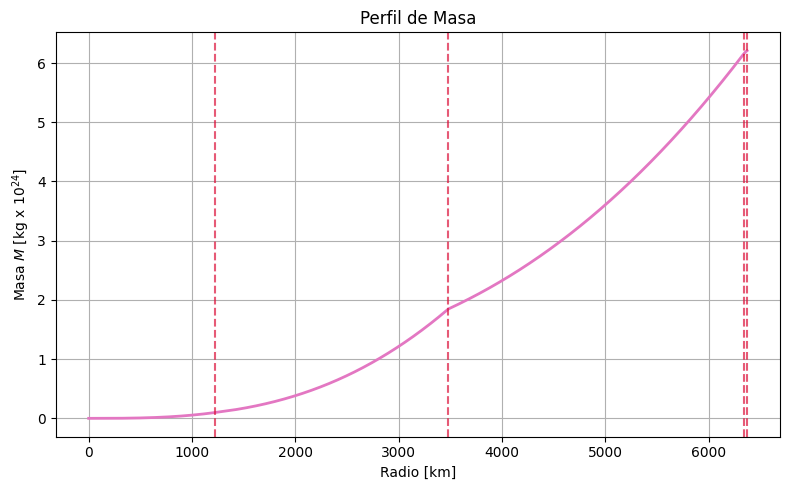

In [140]:
# masa

plt.figure(figsize=(8, 5))
plt.plot(r_km, y_res[2]/1e24, color='C6', lw=2)
plt.xlabel('Radio [km]')
plt.ylabel(r'Masa $M$ [kg x $10^{24}$]')
plt.grid(True)
for boundary in r_limits[:]:
    plt.axvline(boundary/1e3, color='crimson', linestyle='--', alpha=0.7)
plt.title('Perfil de Masa')
plt.tight_layout()
plt.show()

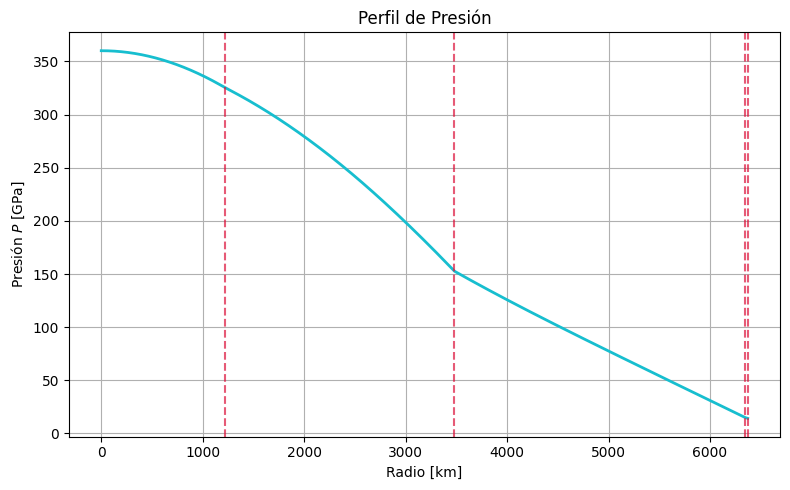

In [141]:
# Presión

plt.figure(figsize=(8, 5))
plt.plot(r_km, y_res[3]/1e9, color='C9', lw=2)
plt.xlabel('Radio [km]')
plt.ylabel(r'Presión $P$ [GPa]')
plt.grid(True)
for boundary in r_limits[:]:
    plt.axvline(boundary/1e3, color='crimson', linestyle='--', alpha=0.7)
plt.title('Perfil de Presión')
plt.tight_layout()
plt.show()

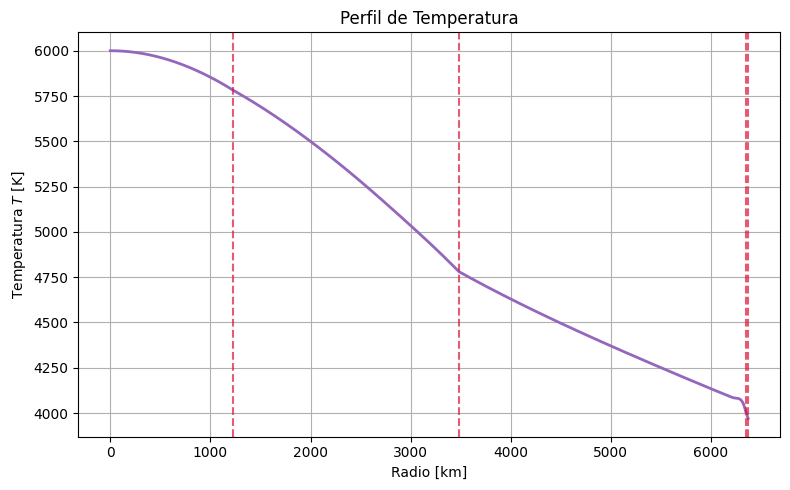

In [142]:
# Temperatura

plt.figure(figsize=(8, 5))
plt.plot(r_km, y_res[4], color='C4', lw=2)
plt.xlabel('Radio [km]')
plt.ylabel(r'Temperatura $T$ [K]')
plt.grid(True)
for boundary in r_limits[:]:
    plt.axvline(boundary/1e3, color='crimson', linestyle='--', alpha=0.7)
plt.title('Perfil de Temperatura')
plt.tight_layout()
plt.show()

In [143]:
# Check final data

print("Final data:")
print(f"Radio final: {r_res[-1]/1e3:.2f} km")
print(f"Densidad final: {y_res[0, -1]/1e3:.2f} g/cm^3")
print(f"Gravedad final: {y_res[1, -1]:.2f} m/s^2")
print(f"Masa final: {y_res[2, -1]/1e24:.2f} kg x $10^{24}$")
print(f"Presión final: {y_res[3, -1]/1e9:.2f} GPa")
print(f"Temperatura final: {y_res[4, -1]:.2f} K")

Final data:
Radio final: 6371.00 km
Densidad final: 2.87 g/cm^3
Gravedad final: 10.21 m/s^2
Masa final: 6.21 kg x $10^24$
Presión final: 14.26 GPa
Temperatura final: 3970.52 K
